<a href="https://colab.research.google.com/github/dev-yooillog/MAIN_QUEST/blob/main/Mini_Project2/Hotel_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus']

import warnings
warnings.filterwarnings('ignore')

In [2]:
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
hotel = pd.read_csv(url)

In [3]:
hotel.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
hotel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
null_counts = hotel.isnull().sum()

In [6]:
null_counts[null_counts > 0].sort_values(ascending=False)

,0
company,112593
agent,16340
country,488
children,4


### 데이터 프로파일링

In [7]:
hotel.isnull().sum().sort_values(ascending=False).head(10)

,0
company,112593
agent,16340
country,488
children,4
arrival_date_month,0
arrival_date_week_number,0
hotel,0
is_canceled,0
stays_in_weekend_nights,0
arrival_date_day_of_month,0


In [8]:
display(hotel.describe())

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


### 결측치 missing values

In [9]:
hotel['children'] = hotel['children'].fillna(0)

In [10]:
hotel['country'] = hotel['country'].fillna('Unknown')

In [11]:
hotel['agent'] = hotel['agent'].fillna(0)
hotel['company'] = hotel['company'].fillna(0)

In [12]:
hotel.isnull().sum().sum()

np.int64(0)

### 데이터 타입 변환 Casting

In [13]:
hotel['children'] = hotel['children'].astype(int)
hotel['agent'] = hotel['agent'].astype(int)
hotel['company'] = hotel['company'].astype(int)

### 이상치

In [14]:
filter_no_guests = (hotel['adults'] + hotel['children'] + hotel['babies']) == 0
hotel = hotel[~filter_no_guests]

In [15]:
filter_no_adults = (hotel['adults'] == 0) & ((hotel['children'] > 0) | hotel['babies'] > 0)
hotel = hotel[~filter_no_adults]

In [16]:
hotel.shape

(118987, 32)

### 중복 데이터 Deuplicates

In [17]:
duplicate_count = hotel.duplicated().sum()

In [18]:
hotel = hotel.drop_duplicates()

In [19]:
hotel.shape

(87011, 32)

### Feature Enginnering

In [20]:
hotel['total_guests'] = hotel['adults'] + hotel['children'] + hotel['babies']

In [21]:
hotel['total_stay_days'] = hotel['stays_in_weekend_nights'] + hotel['stays_in_week_nights']

In [22]:
hotel['is_family'] = hotel.apply(lambda x: 1 if x['children'] + x['babies'] > 0 else 0, axis=1)

In [23]:
display(hotel[['total_guests', 'total_stay_days', 'is_family']].head())

,total_guests,total_stay_days,is_family
0,2,0,0
1,2,0,0
2,1,1,0
3,1,1,0
4,2,2,0


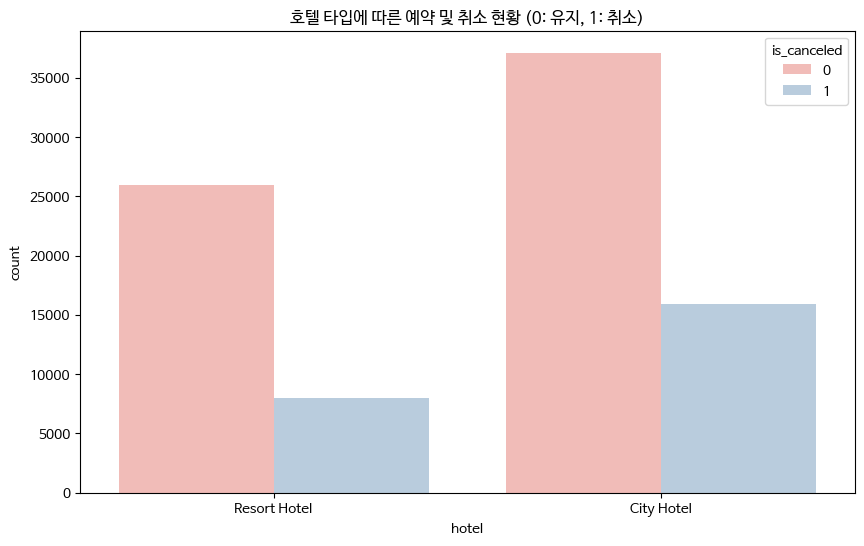

In [24]:
# 호텔 타입별 예약 취소 비율
plt.figure(figsize=(10, 6))
sns.countplot(x='hotel', hue='is_canceled', data=hotel, palette='Pastel1')
plt.title('호텔 타입에 따른 예약 및 취소 현황 (0: 유지, 1: 취소)')
plt.show()

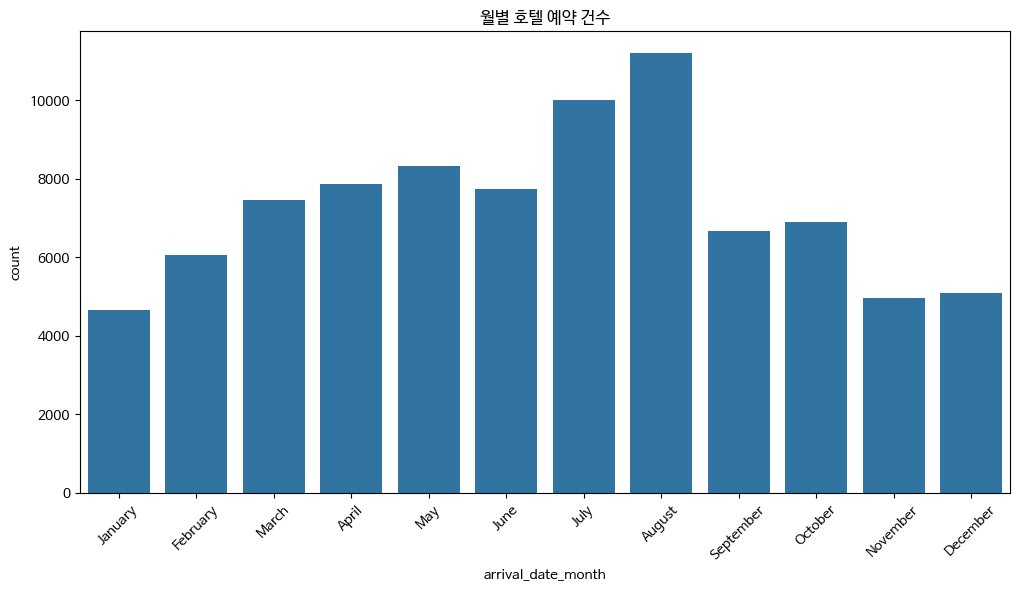

In [25]:
# 월별 예약 건수

plt.figure(figsize=(12, 6))
sns.countplot(x='arrival_date_month', data=hotel,
              order=['January', 'February', 'March', 'April', 'May', 'June',
                     'July', 'August', 'September', 'October', 'November', 'December'])
plt.xticks(rotation=45)
plt.title('월별 호텔 예약 건수')
plt.show()

In [26]:
hotel.to_csv('hotel_bookings_cleaned.csv', index=False)